# Análise Exploratória dos Dados

## Sistema Híbrido de Recomendação de Cursos para Desenvolvimento Profissional

Esta análise exploratória tem como objetivo compreender o comportamento das interações dos usuários com os cursos da Escola Virtual de Governo (EV.G), identificando padrões relevantes para a construção do sistema híbrido de recomendação.

A análise utiliza a base de interações previamente preparada e o catálogo canônico de cursos. As investigações realizadas nesta etapa buscam apoiar principalmente as decisões relacionadas à construção do componente de Filtragem Colaborativa, além de caracterizar os cursos que serão utilizados pelo componente Baseado em Conteúdo.

In [1]:
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

# Caminhos dos dados processados
pasta_dados = Path("../dados/processados")

arquivo_interacoes = pasta_dados / "interacoes_cursos_atuais.parquet"
arquivo_catalogo = pasta_dados / "catalogo_canonico.parquet"

# Conexão com DuckDB
con = duckdb.connect()

print("Base de interações encontrada:", arquivo_interacoes.exists())
print("Catálogo canônico encontrado:", arquivo_catalogo.exists())

Base de interações encontrada: True
Catálogo canônico encontrado: True


## 1. Distribuição das interações entre os usuários

**Pergunta:** Como as interações com os cursos estão distribuídas entre os usuários?

Esta análise busca identificar quantos cursos cada usuário acessou ao longo do histórico e verificar se as interações estão concentradas em usuários muito ativos ou se predominam usuários com poucas interações. Essa característica é relevante para avaliar a densidade dos dados disponíveis para o componente de Filtragem Colaborativa.

In [2]:
interacoes_por_usuario = con.execute(f"""
    SELECT
        codigo_pessoa,
        COUNT(*) AS qtd_interacoes,
        COUNT(DISTINCT id_curso_canonico) AS qtd_cursos
    FROM read_parquet('{arquivo_interacoes.as_posix()}')
    GROUP BY codigo_pessoa
""").df()

interacoes_por_usuario.head()

,codigo_pessoa,qtd_interacoes,qtd_cursos
0,f6e8f39e85,72,72
1,8488850669,2,2
2,c4d957d9ae,1,1
3,63656cc333,12,7
4,2131a630c6,8,4


In [3]:
resumo_usuarios = interacoes_por_usuario[
    ["qtd_interacoes", "qtd_cursos"]
].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

resumo_usuarios

,qtd_interacoes,qtd_cursos
count,6.444712e+06,6.444712e+06
mean,3.314811e+00,2.996204e+00
std,7.646757e+00,5.844564e+00
min,1.000000e+00,1.000000e+00
25%,1.000000e+00,1.000000e+00
50%,1.000000e+00,1.000000e+00
75%,3.000000e+00,3.000000e+00
90%,7.000000e+00,7.000000e+00
95%,1.200000e+01,1.000000e+01
99%,2.600000e+01,2.300000e+01


In [4]:
faixas_usuarios = con.execute(f"""
    WITH cursos_por_usuario AS (
        SELECT
            codigo_pessoa,
            COUNT(DISTINCT id_curso_canonico) AS qtd_cursos
        FROM read_parquet('{arquivo_interacoes.as_posix()}')
        GROUP BY codigo_pessoa
    )

    SELECT
        CASE
            WHEN qtd_cursos = 1 THEN '1 curso'
            WHEN qtd_cursos = 2 THEN '2 cursos'
            WHEN qtd_cursos = 3 THEN '3 cursos'
            WHEN qtd_cursos = 4 THEN '4 cursos'
            ELSE '5 ou mais'
        END AS faixa,
        COUNT(*) AS qtd_usuarios
    FROM cursos_por_usuario
    GROUP BY faixa
""").df()

faixas_usuarios

,faixa,qtd_usuarios
0,2 cursos,1051785
1,1 curso,3572744
2,5 ou mais,1004166
3,3 cursos,509284
4,4 cursos,306733


In [5]:
ordem_faixas = ["1 curso", "2 cursos", "3 cursos", "4 cursos", "5 ou mais"]

faixas_usuarios["percentual"] = (
    faixas_usuarios["qtd_usuarios"]
    / faixas_usuarios["qtd_usuarios"].sum()
    * 100
)

faixas_usuarios["faixa"] = pd.Categorical(
    faixas_usuarios["faixa"],
    categories=ordem_faixas,
    ordered=True
)

faixas_usuarios = faixas_usuarios.sort_values("faixa")

faixas_usuarios

,faixa,qtd_usuarios,percentual
1,1 curso,3572744,55.436829
0,2 cursos,1051785,16.320124
3,3 cursos,509284,7.902355
4,4 cursos,306733,4.759452
2,5 ou mais,1004166,15.581239


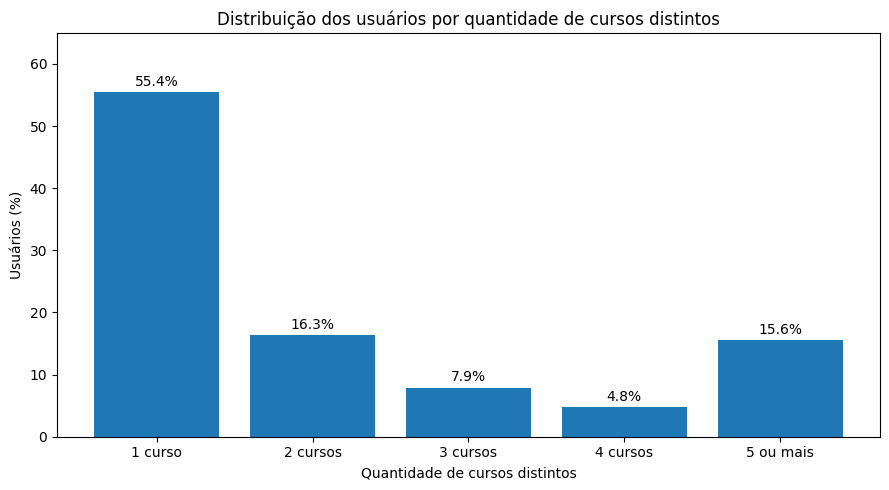

In [6]:
plt.figure(figsize=(9, 5))

barras = plt.bar(
    faixas_usuarios["faixa"].astype(str),
    faixas_usuarios["percentual"]
)

plt.title("Distribuição dos usuários por quantidade de cursos distintos")
plt.xlabel("Quantidade de cursos distintos")
plt.ylabel("Usuários (%)")

plt.ylim(0, 65)

for barra, percentual in zip(barras, faixas_usuarios["percentual"]):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1,
        f"{percentual:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Resultado e interpretação

A distribuição evidencia uma forte concentração de usuários com pouco histórico de interação. Entre os 6.444.712 usuários analisados, 55,44% interagiram com apenas um curso distinto, enquanto 16,32% interagiram com dois cursos. Apenas 15,58% possuem histórico de cinco ou mais cursos distintos.

A média de aproximadamente 3 cursos distintos por usuário é superior à mediana de 1 curso, indicando uma distribuição assimétrica, influenciada por uma parcela menor de usuários com histórico mais extenso.

### Implicação para o sistema de recomendação

A elevada proporção de usuários com poucas interações representa uma limitação para a Filtragem Colaborativa, pois esse método depende do histórico de comportamento para identificar padrões de preferência e similaridade entre usuários ou itens.

Esse resultado reforça a adoção de uma abordagem híbrida. Para usuários com histórico suficiente, o componente colaborativo poderá explorar os padrões de interação, enquanto informações de conteúdo dos cursos e outros critérios poderão complementar as recomendações nos casos em que o histórico individual for reduzido.

## 2. Repetição de interações entre usuário e curso

**Pergunta:** Com que frequência um mesmo usuário possui mais de uma interação com o mesmo curso?

Como o histórico registra matrículas, um usuário pode aparecer mais de uma vez associado ao mesmo curso. Esta análise busca identificar a frequência dessas repetições e avaliar como elas deverão ser representadas no componente de Filtragem Colaborativa.

In [7]:
repeticoes_usuario_curso = con.execute(f"""
    SELECT
        codigo_pessoa,
        id_curso_canonico,
        COUNT(*) AS qtd_interacoes
    FROM read_parquet('{arquivo_interacoes.as_posix()}')
    GROUP BY
        codigo_pessoa,
        id_curso_canonico
""").df()

repeticoes_usuario_curso.head()

,codigo_pessoa,id_curso_canonico,qtd_interacoes
0,34ed26744d,10,1
1,dd48e26567,138,1
2,412ac3dfaf,601,1
3,ea09f830a3,1,1
4,0373b88f2a,625,1


In [8]:
distribuicao_repeticoes = (
    repeticoes_usuario_curso
    .groupby("qtd_interacoes")
    .size()
    .reset_index(name="qtd_pares")
    .sort_values("qtd_interacoes")
)

distribuicao_repeticoes["percentual"] = (
    distribuicao_repeticoes["qtd_pares"]
    / distribuicao_repeticoes["qtd_pares"].sum()
    * 100
)

distribuicao_repeticoes.head(10)

,qtd_interacoes,qtd_pares,percentual
0,1,17651475,91.412623
1,2,1375798,7.124918
2,3,211929,1.097528
3,4,47357,0.245250
4,5,13930,0.072140
5,6,4929,0.025526
6,7,2052,0.010627
7,8,947,0.004904
8,9,512,0.002652
9,10,257,0.001331


### 2.1 Situação das matrículas nos pares repetidos

Após identificar que aproximadamente 8,59% dos pares usuário–curso possuem mais de uma interação, é necessário verificar se essas repetições apresentam sempre a mesma situação de matrícula ou se o usuário possui diferentes situações para um mesmo curso.

Essa análise é importante para definir como múltiplas interações entre o mesmo usuário e curso serão consolidadas posteriormente para a Filtragem Colaborativa, evitando a perda de informações relevantes sobre o histórico de interação.

In [9]:
status_pares_repetidos = con.execute(f"""
    WITH pares_repetidos AS (
        SELECT
            codigo_pessoa,
            id_curso_canonico
        FROM read_parquet('{arquivo_interacoes.as_posix()}')
        GROUP BY
            codigo_pessoa,
            id_curso_canonico
        HAVING COUNT(*) > 1
    )

    SELECT
        COUNT(*) AS total_pares_repetidos,
        SUM(CASE WHEN qtd_status = 1 THEN 1 ELSE 0 END) AS mesmo_status,
        SUM(CASE WHEN qtd_status > 1 THEN 1 ELSE 0 END) AS status_diferentes
    FROM (
        SELECT
            i.codigo_pessoa,
            i.id_curso_canonico,
            COUNT(DISTINCT i.sit_matricula) AS qtd_status
        FROM read_parquet('{arquivo_interacoes.as_posix()}') AS i
        INNER JOIN pares_repetidos AS p
            ON i.codigo_pessoa = p.codigo_pessoa
            AND i.id_curso_canonico = p.id_curso_canonico
        GROUP BY
            i.codigo_pessoa,
            i.id_curso_canonico
    )
""").df()

status_pares_repetidos

,total_pares_repetidos,mesmo_status,status_diferentes
0,1658194,692249.0,965945.0


### Resultado parcial

Foram identificados 1.658.194 pares usuário–curso com mais de uma interação. Desses, aproximadamente 41,75% apresentam a mesma situação de matrícula em todas as interações, enquanto 58,25% apresentam situações diferentes.

Esse resultado indica que as matrículas repetidas não representam apenas registros equivalentes. Em uma parcela significativa dos casos, o histórico registra diferentes resultados de interação de um mesmo usuário com o mesmo curso. Por isso, a definição da regra de consolidação deve considerar também a situação das matrículas.

In [10]:
combinacoes_status = con.execute(f"""
    WITH pares_repetidos AS (
        SELECT
            codigo_pessoa,
            id_curso_canonico
        FROM read_parquet('{arquivo_interacoes.as_posix()}')
        GROUP BY
            codigo_pessoa,
            id_curso_canonico
        HAVING COUNT(*) > 1
    )

    SELECT
        lista_status,
        COUNT(*) AS qtd_pares
    FROM (
        SELECT
            i.codigo_pessoa,
            i.id_curso_canonico,
            STRING_AGG(
                DISTINCT i.sit_matricula,
                ' + '
                ORDER BY i.sit_matricula
            ) AS lista_status
        FROM read_parquet('{arquivo_interacoes.as_posix()}') AS i
        INNER JOIN pares_repetidos AS p
            ON i.codigo_pessoa = p.codigo_pessoa
            AND i.id_curso_canonico = p.id_curso_canonico
        GROUP BY
            i.codigo_pessoa,
            i.id_curso_canonico
    )
    GROUP BY lista_status
    ORDER BY qtd_pares DESC
""").df()

combinacoes_status.head(15)

,lista_status,qtd_pares
0,Concluida + Desistente,670668
1,Desistente,523052
2,Concluida,151770
3,Concluida + Reprovado,86633
4,Concluida + Trancada,58287
5,Desistente + Reprovado,49258
6,Desistente + Trancada,28998
7,Desistente + Não Concluído,28365
8,Concluida + Desistente + Reprovado,16697
9,Reprovado,12000


### 2.2 Combinações de situações nos pares repetidos

Entre os pares usuário–curso com múltiplas interações, a combinação mais frequente de situações foi **Concluída + Desistente**, presente em 670.668 pares. Esse grupo corresponde a aproximadamente 40,45% de todos os pares repetidos e representa a maior parte dos casos em que um mesmo usuário apresenta situações diferentes para o mesmo curso.

Também foram observadas combinações como **Concluída + Reprovado**, **Concluída + Trancada** e **Desistente + Reprovado**, além de pares nos quais todas as interações mantêm a mesma situação.

Como a análise das combinações não considera a ordem das matrículas, torna-se necessário investigar a sequência temporal das situações, especialmente para a combinação predominante entre conclusão e desistência.

In [11]:
ordem_conclusao_desistencia = con.execute(f"""
    WITH pares_alvo AS (
        SELECT
            codigo_pessoa,
            id_curso_canonico
        FROM read_parquet('{arquivo_interacoes.as_posix()}')
        GROUP BY
            codigo_pessoa,
            id_curso_canonico
        HAVING
            COUNT(DISTINCT sit_matricula) = 2
            AND COUNT(DISTINCT CASE
                WHEN sit_matricula IN ('Concluida', 'Desistente')
                THEN sit_matricula
            END) = 2
    ),

    historico AS (
        SELECT
            i.codigo_pessoa,
            i.id_curso_canonico,
            ARG_MIN(i.sit_matricula, i.dt_matricula) AS primeiro_status,
            ARG_MAX(i.sit_matricula, i.dt_matricula) AS ultimo_status
        FROM read_parquet('{arquivo_interacoes.as_posix()}') AS i
        INNER JOIN pares_alvo AS p
            ON i.codigo_pessoa = p.codigo_pessoa
            AND i.id_curso_canonico = p.id_curso_canonico
        GROUP BY
            i.codigo_pessoa,
            i.id_curso_canonico
    )

    SELECT
        primeiro_status,
        ultimo_status,
        COUNT(*) AS qtd_pares
    FROM historico
    GROUP BY
        primeiro_status,
        ultimo_status
    ORDER BY qtd_pares DESC
""").df()

ordem_conclusao_desistencia 

,primeiro_status,ultimo_status,qtd_pares
0,Desistente,Concluida,531238
1,Concluida,Desistente,114715
2,Desistente,Desistente,15756
3,Concluida,Concluida,8959


### Resultado e interpretação

A análise temporal da combinação mais frequente revelou que, entre os 670.668 pares usuário–curso que apresentam situações de **Concluída** e **Desistente**, 531.238 (79,21%) possuem uma desistência como primeira situação e uma conclusão como última situação. Em 114.715 casos (17,10%), ocorre o comportamento inverso.

Também foram identificados pares nos quais o primeiro e o último status são iguais, apesar da existência dos dois tipos de situação no histórico. Isso ocorre quando há mais de duas matrículas para o mesmo par usuário–curso e uma situação diferente aparece em uma interação intermediária.

### Implicação para o sistema de recomendação

Os resultados mostram que múltiplas matrículas de um mesmo usuário em um curso podem representar uma evolução do seu histórico de interação. Em particular, a predominância da sequência iniciada por desistência e finalizada por conclusão indica que a desistência não deve ser interpretada automaticamente como ausência de interesse pelo curso.

Dessa forma, as interações repetidas não serão simplesmente eliminadas antes da modelagem. Para a construção da representação usuário–curso utilizada pela Filtragem Colaborativa, será necessário consolidar o histórico de cada par considerando as diferentes situações registradas e sua evolução temporal.

## 3. Distribuição das interações entre os cursos

**Pergunta:** Como as interações estão distribuídas entre os cursos?

Esta análise busca verificar se as interações dos usuários estão distribuídas de forma equilibrada entre os cursos ou se existe concentração em um grupo menor de cursos mais populares. A identificação desse padrão é relevante para o sistema de recomendação, pois uma forte concentração pode influenciar o componente de Filtragem Colaborativa e favorecer a recomendação de itens já populares.

In [12]:
interacoes_por_curso = con.execute(f"""
    SELECT
        id_curso_canonico,
        COUNT(*) AS qtd_interacoes,
        COUNT(DISTINCT codigo_pessoa) AS qtd_usuarios
    FROM read_parquet('{arquivo_interacoes.as_posix()}')
    GROUP BY id_curso_canonico
""").df()

interacoes_por_curso.head()

,id_curso_canonico,qtd_interacoes,qtd_usuarios
0,176,36740,33908
1,606,298348,266394
2,826,127308,119222
3,479,87334,78737
4,188,107171,101897


In [13]:
resumo_cursos = interacoes_por_curso[
    ["qtd_interacoes", "qtd_usuarios"]
].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

resumo_cursos

,qtd_interacoes,qtd_usuarios
count,1030.000000,1030.000000
mean,20740.778641,18747.251456
std,49500.592192,42583.802305
min,72.000000,69.000000
25%,3419.250000,3215.250000
50%,8572.000000,8031.000000
75%,20046.500000,18686.000000
90%,41531.000000,38381.600000
95%,73999.600000,66274.700000
99%,205194.320000,182710.800000


### 3.1 Concentração das interações nos cursos mais populares

**Pergunta:** Quanto das interações está concentrado nos cursos mais populares?

Além de observar a distribuição do número de interações por curso, é importante avaliar se uma parcela pequena dos cursos concentra grande parte das interações registradas.

Para isso, será analisada a proporção de interações acumulada pelos 10%, 20% e 50% dos cursos com maior número de interações. Essa análise permite avaliar a concentração de popularidade no catálogo e suas possíveis implicações para o sistema de recomendação.

In [14]:
cursos_ordenados = (
    interacoes_por_curso
    .sort_values("qtd_interacoes", ascending=False)
    .reset_index(drop=True)
)

total_interacoes = cursos_ordenados["qtd_interacoes"].sum()
total_cursos = len(cursos_ordenados)

concentracao = []

for percentual_cursos in [0.10, 0.20, 0.50]:
    quantidade = round(total_cursos * percentual_cursos)

    interacoes_top = (
        cursos_ordenados
        .head(quantidade)["qtd_interacoes"]
        .sum()
    )

    concentracao.append({
        "top_cursos": f"{int(percentual_cursos * 100)}%",
        "qtd_cursos": quantidade,
        "percentual_interacoes": interacoes_top / total_interacoes * 100
    })

concentracao = pd.DataFrame(concentracao)

concentracao

,top_cursos,qtd_cursos,percentual_interacoes
0,10%,103,53.894724
1,20%,206,69.464460
2,50%,515,91.093274


### Resultado e interpretação

A análise evidencia uma forte concentração das interações em uma parcela menor dos cursos. Os 10% de cursos mais populares concentram aproximadamente 53,89% de todas as interações registradas, enquanto os 20% mais populares representam 69,46% das interações.

Ao considerar metade dos cursos, a concentração alcança 91,09% das interações. Consequentemente, os 50% de cursos menos populares respondem por apenas 8,91% do histórico analisado.

Esses resultados indicam uma distribuição assimétrica de popularidade entre os cursos, na qual uma parcela relativamente pequena do catálogo possui grande quantidade de interações, enquanto muitos cursos apresentam menor volume de histórico.

### Implicação para o sistema de recomendação

A concentração de interações nos cursos mais populares deve ser considerada na construção do sistema, pois o componente de Filtragem Colaborativa dispõe de maior quantidade de informações sobre esses cursos e pode, consequentemente, favorecer itens já populares.

A combinação com o componente Baseado em Conteúdo pode contribuir para ampliar a possibilidade de recomendação de cursos menos populares quando suas características forem compatíveis com os interesses identificados para o usuário, reduzindo a dependência exclusiva da popularidade observada no histórico.

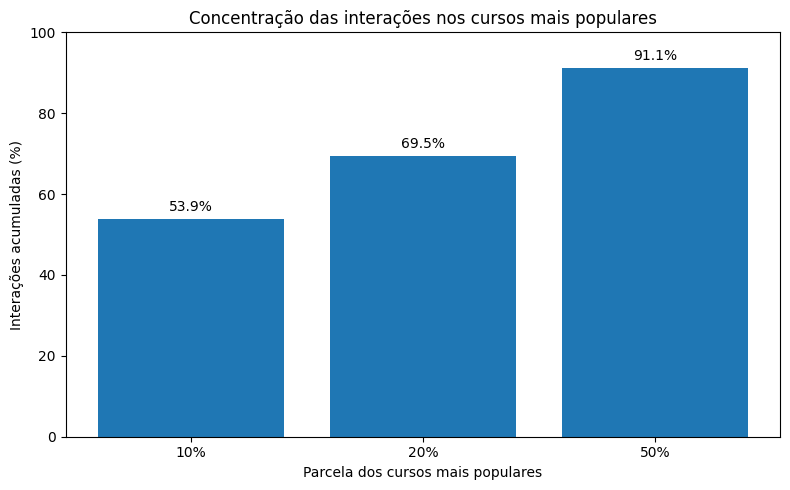

In [15]:
plt.figure(figsize=(8, 5))

barras = plt.bar(
    concentracao["top_cursos"],
    concentracao["percentual_interacoes"]
)

plt.title("Concentração das interações nos cursos mais populares")
plt.xlabel("Parcela dos cursos mais populares")
plt.ylabel("Interações acumuladas (%)")

plt.ylim(0, 100)

for barra, percentual in zip(
    barras,
    concentracao["percentual_interacoes"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 2,
        f"{percentual:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### 3.2 Distribuição de popularidade e cauda longa

**Pergunta:** A distribuição de popularidade dos cursos apresenta um padrão de cauda longa?

Após identificar a concentração das interações nos cursos mais populares, esta análise busca observar como o volume de interações se distribui ao longo de todo o catálogo.

A identificação de uma possível cauda longa é relevante para o sistema de recomendação, pois cursos com menor número de interações fornecem menos informações comportamentais para a Filtragem Colaborativa, embora ainda possam ser relevantes para determinados usuários.

In [16]:
popularidade_ordenada = (
    interacoes_por_curso
    .sort_values("qtd_interacoes", ascending=False)
    .reset_index(drop=True)
)

popularidade_ordenada["posicao"] = (
    popularidade_ordenada.index + 1
)

popularidade_ordenada.head()

,id_curso_canonico,qtd_interacoes,qtd_usuarios,posicao
0,89,801486,638755,1
1,568,738565,646093,2
2,1023,616618,529283,3
3,606,298348,266394,4
4,624,258711,216361,5


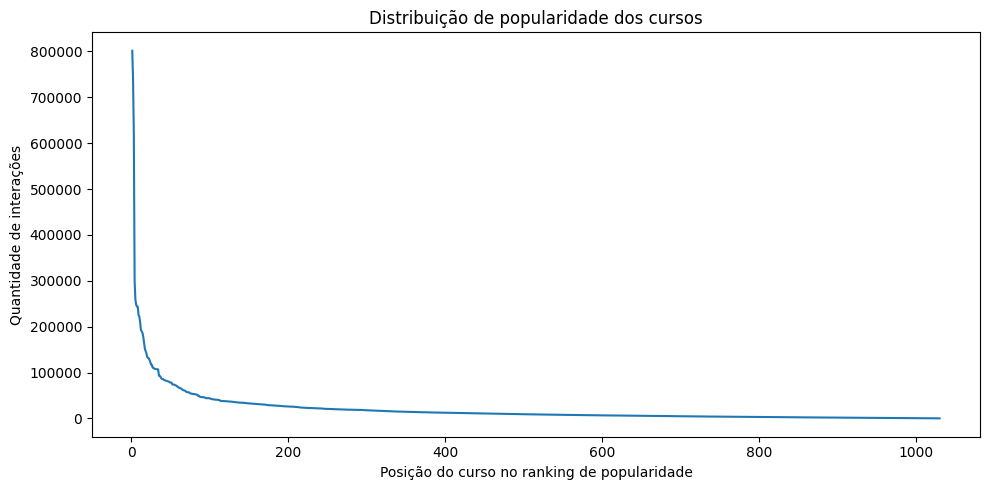

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(
    popularidade_ordenada["posicao"],
    popularidade_ordenada["qtd_interacoes"]
)

plt.title("Distribuição de popularidade dos cursos")
plt.xlabel("Posição do curso no ranking de popularidade")
plt.ylabel("Quantidade de interações")

plt.tight_layout()
plt.show()

### Resultado e interpretação

A distribuição ordenada da popularidade apresenta uma queda acentuada nas primeiras posições, seguida por uma extensa região composta por cursos com volumes progressivamente menores de interação. Esse comportamento caracteriza um padrão de cauda longa na distribuição de popularidade dos cursos.

O resultado complementa a análise de concentração realizada anteriormente: enquanto uma parcela relativamente pequena dos cursos concentra grande parte das interações, uma quantidade expressiva de cursos permanece na cauda da distribuição, com menor volume de histórico disponível.

### Implicação para o sistema de recomendação

O padrão de cauda longa representa um desafio para a Filtragem Colaborativa, pois os cursos menos populares possuem menor quantidade de interações a partir das quais o modelo pode identificar padrões comportamentais.

Nesse contexto, o componente Baseado em Conteúdo torna-se especialmente relevante, pois permite explorar características dos próprios cursos para identificar similaridades, inclusive para itens com menor volume de interações. A combinação das duas abordagens pode, portanto, reduzir a dependência exclusiva da popularidade histórica.

## 4. Distribuição das situações de matrícula

**Pergunta:** Como as diferentes situações de matrícula estão distribuídas no histórico de interações?

As situações de matrícula representam diferentes resultados das interações dos usuários com os cursos. A análise de sua distribuição permite compreender a frequência de conclusões, desistências, reprovações, trancamentos e matrículas ainda não concluídas.

Essa informação é especialmente relevante para a definição do sinal de interação utilizado pela Filtragem Colaborativa, uma vez que a existência de uma matrícula indica interação com o curso, mas as diferentes situações podem representar comportamentos distintos. 

In [18]:
distribuicao_status = con.execute(f"""
    SELECT
        sit_matricula,
        COUNT(*) AS qtd_interacoes
    FROM read_parquet('{arquivo_interacoes.as_posix()}')
    GROUP BY sit_matricula
    ORDER BY qtd_interacoes DESC
""").df()

distribuicao_status["percentual"] = (
    distribuicao_status["qtd_interacoes"]
    / distribuicao_status["qtd_interacoes"].sum()
    * 100
)

distribuicao_status

,sit_matricula,qtd_interacoes,percentual
0,Concluida,10035834,46.977639
1,Desistente,9683003,45.326041
2,Reprovado,679838,3.182315
3,Não Concluído,523954,2.452623
4,Trancada,440373,2.061382


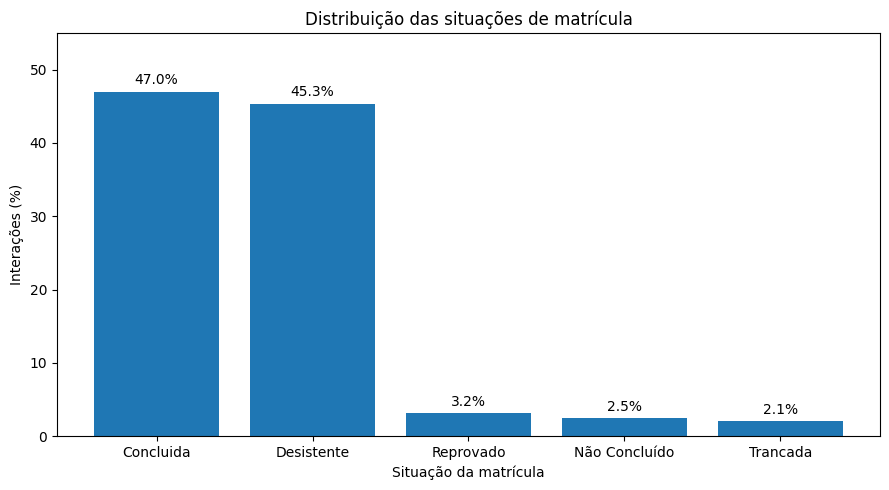

In [19]:
plt.figure(figsize=(9, 5))

barras = plt.bar(
    distribuicao_status["sit_matricula"],
    distribuicao_status["percentual"]
)

plt.title("Distribuição das situações de matrícula")
plt.xlabel("Situação da matrícula")
plt.ylabel("Interações (%)")

plt.ylim(0, 55)

for barra, percentual in zip(
    barras,
    distribuicao_status["percentual"]
):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 1,
        f"{percentual:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Resultado e interpretação

As situações **Concluída** e **Desistente** predominam no histórico analisado, representando, respectivamente, 46,98% e 45,33% das interações. As demais situações apresentam proporções consideravelmente menores: **Reprovado** corresponde a 3,18%, **Não Concluído** a 2,45% e **Trancada** a 2,06%.

A elevada frequência de desistências não deve ser interpretada isoladamente como ausência de interesse pelo curso. A análise das interações repetidas mostrou que um mesmo usuário pode apresentar diferentes situações para o mesmo curso e que, entre os pares com situações de conclusão e desistência, é frequente a ocorrência de desistência seguida posteriormente por conclusão.

### Implicação para o sistema de recomendação

As situações de matrícula fornecem informações adicionais sobre o resultado das interações, mas não representam avaliações explícitas de preferência. A matrícula em um curso constitui um sinal de interação, enquanto sua situação acrescenta contexto sobre o comportamento observado.

Dessa forma, a utilização das situações no componente de Filtragem Colaborativa deverá considerar seu significado e o histórico do par usuário–curso, evitando interpretar automaticamente situações como desistência, reprovação ou trancamento como avaliações negativas.

### 4.1 Variação das situações de matrícula entre os cursos

**Pergunta:** As proporções de conclusão e desistência são semelhantes entre os cursos ou existem diferenças relevantes?

A distribuição geral das situações de matrícula mostra proporções próximas de conclusões e desistências. Entretanto, esse resultado agregado pode ocultar diferenças entre os cursos.

Esta análise busca verificar como as taxas de conclusão e desistência variam entre os cursos, permitindo identificar se determinados cursos apresentam padrões de comportamento distintos no histórico de interações.

In [20]:
status_por_curso = con.execute(f"""
    SELECT
        id_curso_canonico,
        COUNT(*) AS total_interacoes,

        SUM(
            CASE WHEN sit_matricula = 'Concluida'
            THEN 1 ELSE 0 END
        ) AS concluidas,

        SUM(
            CASE WHEN sit_matricula = 'Desistente'
            THEN 1 ELSE 0 END
        ) AS desistentes

    FROM read_parquet('{arquivo_interacoes.as_posix()}')
    GROUP BY id_curso_canonico
""").df()

status_por_curso["taxa_conclusao"] = (
    status_por_curso["concluidas"]
    / status_por_curso["total_interacoes"]
    * 100
)

status_por_curso["taxa_desistencia"] = (
    status_por_curso["desistentes"]
    / status_por_curso["total_interacoes"]
    * 100
)

status_por_curso.head()

,id_curso_canonico,total_interacoes,concluidas,desistentes,taxa_conclusao,taxa_desistencia
0,1,10714,3173.0,6594.0,29.615456,61.545641
1,2,681,295.0,316.0,43.318649,46.402349
2,3,795,573.0,179.0,72.075472,22.515723
3,4,5271,2058.0,2690.0,39.043825,51.033959
4,5,186,127.0,49.0,68.279570,26.344086


In [21]:
resumo_taxas_cursos = status_por_curso[
    ["taxa_conclusao", "taxa_desistencia"]
].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

resumo_taxas_cursos

,taxa_conclusao,taxa_desistencia
count,1030.000000,1030.000000
mean,46.295202,41.367562
std,13.419606,15.189303
min,0.000000,0.000000
25%,37.572515,33.409853
50%,46.596200,43.889669
75%,54.846655,51.324141
90%,63.075062,58.485408
95%,68.377339,62.518189
99%,75.704326,68.897554


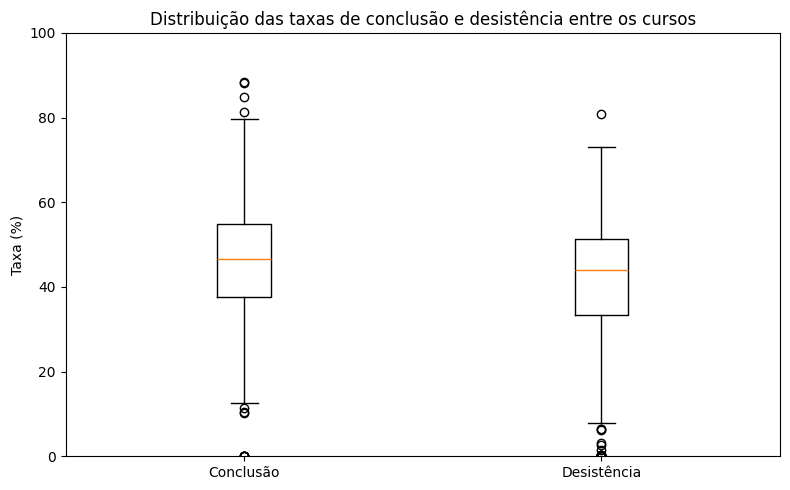

In [22]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        status_por_curso["taxa_conclusao"],
        status_por_curso["taxa_desistencia"]
    ],
    tick_labels=["Conclusão", "Desistência"]
)

plt.title("Distribuição das taxas de conclusão e desistência entre os cursos")
plt.ylabel("Taxa (%)")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

### Resultado e interpretação

As taxas de conclusão e desistência apresentam variação relevante entre os cursos. A mediana da taxa de conclusão é de aproximadamente 46,60%, sendo que 50% dos cursos apresentam taxas entre 37,57% e 54,85%. Para a desistência, também é observada dispersão significativa entre os cursos.

A amplitude observada indica que a distribuição geral das situações de matrícula não representa igualmente o comportamento de todos os cursos. Alguns cursos apresentam proporções de conclusão ou desistência consideravelmente diferentes das observadas no conjunto total de interações.

As taxas extremas devem ser interpretadas com cautela, pois os cursos possuem volumes distintos de interações e percentuais elevados ou reduzidos podem estar associados a cursos com menor número de matrículas.

### Implicação para o sistema de recomendação

A variação entre os cursos reforça que a situação da matrícula não deve ser utilizada isoladamente como uma medida direta de preferência do usuário. O resultado observado pode estar relacionado tanto ao comportamento individual quanto às características do próprio curso.

Por esse motivo, características dos cursos poderão ser analisadas em conjunto com as situações de matrícula, buscando identificar possíveis padrões relevantes para a compreensão das interações.

## 5. Relação entre características dos cursos e as situações de matrícula

**Pergunta:** Características dos cursos, como carga horária e prazo disponível, apresentam diferenças nos padrões de conclusão e desistência?

Após identificar variações nas taxas de conclusão e desistência entre os cursos, esta análise busca investigar se características relacionadas aos próprios cursos apresentam associação com os diferentes resultados das matrículas.

Inicialmente serão analisadas a carga horária e o período disponível para realização do curso. O objetivo é identificar padrões que auxiliem na compreensão das interações, sem estabelecer relações de causalidade entre essas características e a situação da matrícula.

In [23]:
distribuicao_carga_horaria = con.execute(f"""
    SELECT
        carga_horaria,
        COUNT(*) AS qtd_interacoes
    FROM read_parquet('{arquivo_interacoes.as_posix()}')
    GROUP BY carga_horaria
    ORDER BY carga_horaria
""").df()

distribuicao_carga_horaria.head(15)

,carga_horaria,qtd_interacoes
0,1,57980
1,2,275759
2,3,30521
3,4,257160
4,5,132051
5,6,183031
6,7,6935
7,8,360732
8,9,8850
9,10,1451926


In [24]:
resumo_carga_horaria = con.execute(f"""
    SELECT
        MIN(carga_horaria) AS minimo,
        QUANTILE_CONT(carga_horaria, 0.25) AS q1,
        MEDIAN(carga_horaria) AS mediana,
        QUANTILE_CONT(carga_horaria, 0.75) AS q3,
        QUANTILE_CONT(carga_horaria, 0.90) AS p90,
        QUANTILE_CONT(carga_horaria, 0.95) AS p95,
        QUANTILE_CONT(carga_horaria, 0.99) AS p99,
        MAX(carga_horaria) AS maximo,
        AVG(carga_horaria) AS media
    FROM read_parquet('{arquivo_interacoes.as_posix()}')
""").df()

resumo_carga_horaria

,minimo,q1,mediana,q3,p90,p95,p99,maximo,media
0,1,20.0,25.0,30.0,50.0,60.0,100.0,235,27.678904


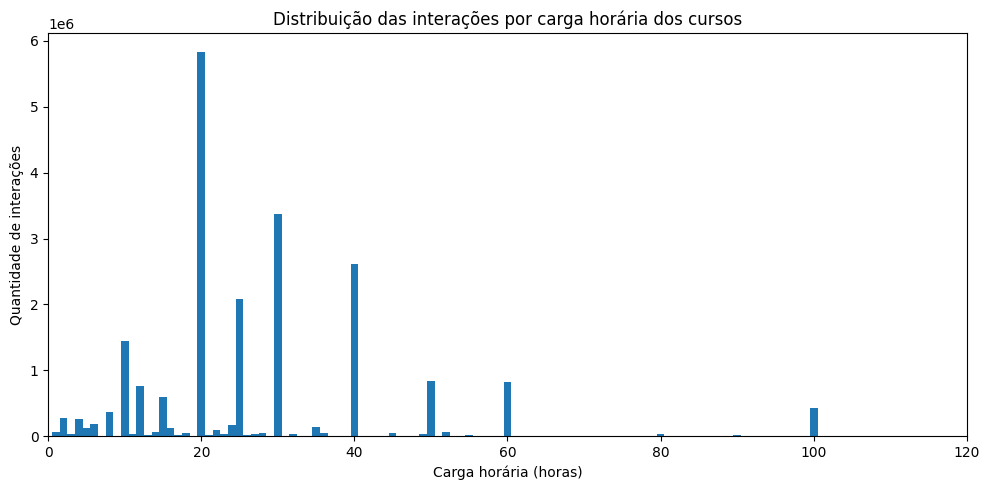

In [25]:
plt.figure(figsize=(10, 5))

plt.bar(
    distribuicao_carga_horaria["carga_horaria"],
    distribuicao_carga_horaria["qtd_interacoes"],
    width=1
)

plt.title("Distribuição das interações por carga horária dos cursos")
plt.xlabel("Carga horária (horas)")
plt.ylabel("Quantidade de interações")

plt.xlim(0, 120)

plt.tight_layout()
plt.show()

### 5.1 Carga horária e situação da matrícula

**Pergunta:** As proporções de conclusão e desistência variam de acordo com a carga horária dos cursos?

A distribuição das interações mostra maior concentração em determinadas cargas horárias, especialmente em cursos de 20, 30 e 40 horas, além de menor frequência de interações em cargas mais elevadas.

Para facilitar a comparação dos resultados das matrículas, os cursos serão agrupados em faixas de carga horária. O objetivo é verificar se diferentes durações apresentam padrões distintos de conclusão e desistência, sem assumir relação causal entre essas variáveis.

In [26]:
carga_status = con.execute(f"""
    SELECT
        CASE
            WHEN carga_horaria <= 10 THEN 'Até 10h'
            WHEN carga_horaria <= 20 THEN '11 a 20h'
            WHEN carga_horaria <= 30 THEN '21 a 30h'
            WHEN carga_horaria <= 40 THEN '31 a 40h'
            WHEN carga_horaria <= 60 THEN '41 a 60h'
            ELSE 'Mais de 60h'
        END AS faixa_carga,

        COUNT(*) AS total_interacoes,

        SUM(CASE
            WHEN sit_matricula = 'Concluida'
            THEN 1 ELSE 0
        END) AS concluidas,

        SUM(CASE
            WHEN sit_matricula = 'Desistente'
            THEN 1 ELSE 0
        END) AS desistentes

    FROM read_parquet('{arquivo_interacoes.as_posix()}')

    GROUP BY faixa_carga
""").df()

carga_status

,faixa_carga,total_interacoes,concluidas,desistentes
0,21 a 30h,5893202,2711505.0,2771332.0
1,41 a 60h,1822155,631640.0,995062.0
2,11 a 20h,7485968,3802058.0,3187374.0
3,Mais de 60h,555460,213153.0,280747.0
4,31 a 40h,2841272,1236805.0,1340315.0
5,Até 10h,2764945,1440673.0,1108173.0


In [27]:
carga_status["taxa_conclusao"] = (
    carga_status["concluidas"]
    / carga_status["total_interacoes"]
    * 100
)

carga_status["taxa_desistencia"] = (
    carga_status["desistentes"]
    / carga_status["total_interacoes"]
    * 100
)

ordem_carga = [
    "Até 10h",
    "11 a 20h",
    "21 a 30h",
    "31 a 40h",
    "41 a 60h",
    "Mais de 60h"
]

carga_status["faixa_carga"] = pd.Categorical(
    carga_status["faixa_carga"],
    categories=ordem_carga,
    ordered=True
)

carga_status = carga_status.sort_values("faixa_carga")

carga_status[
    ["faixa_carga", "total_interacoes",
     "taxa_conclusao", "taxa_desistencia"]
]

,faixa_carga,total_interacoes,taxa_conclusao,taxa_desistencia
5,Até 10h,2764945,52.104942,40.079387
2,11 a 20h,7485968,50.789130,42.577981
0,21 a 30h,5893202,46.010726,47.025912
4,31 a 40h,2841272,43.529975,47.173062
1,41 a 60h,1822155,34.664450,54.609076
3,Mais de 60h,555460,38.374140,50.543153


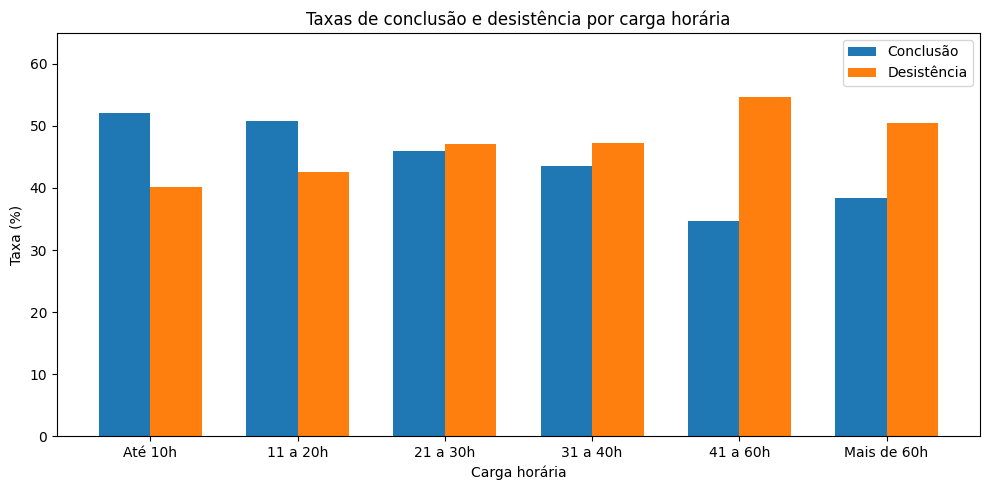

In [28]:
import numpy as np

x = np.arange(len(carga_status))
largura = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - largura / 2,
    carga_status["taxa_conclusao"],
    largura,
    label="Conclusão"
)

plt.bar(
    x + largura / 2,
    carga_status["taxa_desistencia"],
    largura,
    label="Desistência"
)

plt.title("Taxas de conclusão e desistência por carga horária")
plt.xlabel("Carga horária")
plt.ylabel("Taxa (%)")

plt.xticks(
    x,
    carga_status["faixa_carga"].astype(str)
)

plt.ylim(0, 65)
plt.legend()

plt.tight_layout()
plt.show()

### Resultado e interpretação

Os resultados indicam diferenças nos padrões de conclusão e desistência entre as faixas de carga horária. Nos cursos de até 10 horas, a taxa de conclusão é de 52,10%, enquanto a taxa de desistência é de 40,08%. Entre 11 e 20 horas, as taxas são de 50,79% e 42,58%, respectivamente.

A partir da faixa de 21 a 30 horas, a proporção de desistências passa a superar ligeiramente a de conclusões. A maior diferença é observada entre 41 e 60 horas, faixa em que a conclusão corresponde a 34,66% das interações e a desistência a 54,61%.

De maneira geral, observa-se uma tendência de redução da proporção de conclusões e aumento da proporção de desistências nas faixas de maior carga horária. Entretanto, o comportamento não é estritamente crescente ou decrescente, uma vez que os cursos com mais de 60 horas apresentam taxa de conclusão superior à observada na faixa de 41 a 60 horas.

### Implicação para o sistema de recomendação

Os resultados indicam uma associação entre a carga horária dos cursos e os diferentes resultados das matrículas. Essa associação não permite estabelecer uma relação causal, pois outros fatores podem influenciar simultaneamente o comportamento dos usuários.

Ainda assim, a carga horária constitui uma característica relevante dos cursos e poderá ser considerada na representação utilizada pelo componente Baseado em Conteúdo, contribuindo para diferenciar cursos com características distintas.

### 5.2 Prazo disponível e situação da matrícula

**Pergunta:** O tempo disponível para realização do curso apresenta diferenças nos padrões de conclusão e desistência?

Além da carga horária, o período disponível para realização do curso pode representar uma característica relevante da experiência do usuário. Nesta análise, o prazo disponível será calculado pela diferença entre a data de término do curso para o aluno (`dt_fim`) e a data de matrícula (`dt_matricula`).

Esse intervalo representa o período disponível para realização do curso e não o tempo efetivamente utilizado pelo aluno para concluí-lo. O objetivo é investigar possíveis associações entre esse período e as situações de conclusão e desistência, sem estabelecer relação causal.

In [29]:
resumo_prazo = con.execute(f"""
    SELECT
        MIN(DATE_DIFF('day', dt_matricula, dt_fim)) AS minimo,
        QUANTILE_CONT(
            DATE_DIFF('day', dt_matricula, dt_fim), 0.25
        ) AS q1,
        MEDIAN(
            DATE_DIFF('day', dt_matricula, dt_fim)
        ) AS mediana,
        QUANTILE_CONT(
            DATE_DIFF('day', dt_matricula, dt_fim), 0.75
        ) AS q3,
        QUANTILE_CONT(
            DATE_DIFF('day', dt_matricula, dt_fim), 0.90
        ) AS p90,
        QUANTILE_CONT(
            DATE_DIFF('day', dt_matricula, dt_fim), 0.95
        ) AS p95,
        QUANTILE_CONT(
            DATE_DIFF('day', dt_matricula, dt_fim), 0.99
        ) AS p99,
        MAX(DATE_DIFF('day', dt_matricula, dt_fim)) AS maximo,
        AVG(DATE_DIFF('day', dt_matricula, dt_fim)) AS media
    FROM read_parquet('{arquivo_interacoes.as_posix()}')
""").df()

resumo_prazo

,minimo,q1,mediana,q3,p90,p95,p99,maximo,media
0,-340,30.0,30.0,30.0,60.0,60.0,365.0,3650,47.653716


#### Verificação de valores extremos do prazo disponível

A análise inicial identificou valores extremos no prazo disponível, incluindo intervalos negativos e períodos consideravelmente superiores aos valores predominantes de 30 e 60 dias.

Antes de utilizar essa variável na análise das situações de matrícula, será verificada a frequência desses registros para avaliar sua representatividade e possíveis inconsistências.

In [30]:
verificacao_prazo = con.execute(f"""
    SELECT
        COUNT(*) AS total_interacoes,

        SUM(CASE
            WHEN DATE_DIFF('day', dt_matricula, dt_fim) < 0
            THEN 1 ELSE 0
        END) AS prazos_negativos,

        SUM(CASE
            WHEN DATE_DIFF('day', dt_matricula, dt_fim) = 0
            THEN 1 ELSE 0
        END) AS prazo_zero,

        SUM(CASE
            WHEN DATE_DIFF('day', dt_matricula, dt_fim) > 365
            THEN 1 ELSE 0
        END) AS acima_365_dias,

        SUM(CASE
            WHEN DATE_DIFF('day', dt_matricula, dt_fim) = 3650
            THEN 1 ELSE 0
        END) AS prazo_3650_dias

    FROM read_parquet('{arquivo_interacoes.as_posix()}')
""").df()

verificacao_prazo

,total_interacoes,prazos_negativos,prazo_zero,acima_365_dias,prazo_3650_dias
0,21363002,58.0,31.0,81853.0,81533.0


#### Investigação dos prazos de 3.650 dias

A maior parte dos registros com prazo superior a um ano apresenta exatamente 3.650 dias de intervalo entre a matrícula e a data de término. Como esse valor corresponde a aproximadamente dez anos e aparece de forma recorrente, será investigada sua distribuição temporal e entre os cursos antes de definir seu tratamento na análise.

In [31]:
prazo_3650_por_ano = con.execute(f"""
    SELECT
        EXTRACT(YEAR FROM dt_matricula) AS ano,
        COUNT(*) AS qtd_interacoes
    FROM read_parquet('{arquivo_interacoes.as_posix()}')
    WHERE DATE_DIFF('day', dt_matricula, dt_fim) = 3650
    GROUP BY ano
    ORDER BY ano
""").df()

prazo_3650_por_ano

,ano,qtd_interacoes
0,2025,23656
1,2026,57877


In [32]:
prazo_3650_por_curso = con.execute(f"""
    SELECT
        id_curso_canonico,
        nome_curso,
        COUNT(*) AS qtd_interacoes
    FROM read_parquet('{arquivo_interacoes.as_posix()}')
    WHERE DATE_DIFF('day', dt_matricula, dt_fim) = 3650
    GROUP BY id_curso_canonico, nome_curso
    ORDER BY qtd_interacoes DESC
""").df()

print(
    "Cursos distintos:",
    prazo_3650_por_curso["id_curso_canonico"].nunique()
)

prazo_3650_por_curso.head(15)

Cursos distintos: 6


,id_curso_canonico,nome_curso,qtd_interacoes
0,340,Eixo 1 - Programa de Desenvolvimento Inicial p...,19488
1,341,PDI NS - Eixo 2 - Organização do Estado Democ...,15772
2,364,PDI NS - Eixo 3 - Políticas Públicas,14021
3,342,PDI NS - Eixo 4 - Organização da Administração...,12931
4,374,PDI NS Eixo 5 - Orçamento e Finanças Públicas,10752
5,32,PDI NS - Eixo 6 - Desafios do Estado Brasileiro,8569


#### Tratamento dos valores extremos

A investigação dos prazos superiores a 365 dias mostrou que 81.533 registros apresentam exatamente 3.650 dias de intervalo. Esses registros estão concentrados em apenas seis cursos relacionados aos eixos do Programa de Desenvolvimento Inicial (PDI NS) e ocorrem exclusivamente em matrículas realizadas em 2025 e 2026.

Esse padrão indica que os prazos de 3.650 dias não estão distribuídos aleatoriamente na base, mas associados a um conjunto específico de cursos. Como os dados disponíveis não permitem determinar a razão operacional dessa configuração, esses registros não serão classificados como erros nem removidos da base processada.

Para a análise específica da relação entre prazo disponível e situação da matrícula, entretanto, serão considerados separadamente os valores extremos, evitando que uma configuração particular de poucos cursos distorça a caracterização do comportamento predominante do conjunto de dados.

In [33]:
resumo_prazo_analise = con.execute(f"""
    SELECT
        COUNT(*) AS total_interacoes,
        MIN(DATE_DIFF('day', dt_matricula, dt_fim)) AS minimo,
        QUANTILE_CONT(
            DATE_DIFF('day', dt_matricula, dt_fim), 0.25
        ) AS q1,
        MEDIAN(
            DATE_DIFF('day', dt_matricula, dt_fim)
        ) AS mediana,
        QUANTILE_CONT(
            DATE_DIFF('day', dt_matricula, dt_fim), 0.75
        ) AS q3,
        QUANTILE_CONT(
            DATE_DIFF('day', dt_matricula, dt_fim), 0.90
        ) AS p90,
        QUANTILE_CONT(
            DATE_DIFF('day', dt_matricula, dt_fim), 0.95
        ) AS p95,
        MAX(DATE_DIFF('day', dt_matricula, dt_fim)) AS maximo,
        AVG(DATE_DIFF('day', dt_matricula, dt_fim)) AS media

    FROM read_parquet('{arquivo_interacoes.as_posix()}')

    WHERE DATE_DIFF('day', dt_matricula, dt_fim)
          BETWEEN 0 AND 365
""").df()

resumo_prazo_analise

,total_interacoes,minimo,q1,mediana,q3,p90,p95,maximo,media
0,21281091,0,30.0,30.0,30.0,60.0,60.0,365,33.847653


In [34]:
prazos_frequentes = con.execute(f"""
    SELECT
        DATE_DIFF('day', dt_matricula, dt_fim) AS prazo_dias,
        COUNT(*) AS qtd_interacoes
    FROM read_parquet('{arquivo_interacoes.as_posix()}')
    WHERE DATE_DIFF('day', dt_matricula, dt_fim)
          BETWEEN 0 AND 365
    GROUP BY prazo_dias
    ORDER BY qtd_interacoes DESC
    LIMIT 15
""").df()

prazos_frequentes["percentual"] = (
    prazos_frequentes["qtd_interacoes"]
    / 21281091
    * 100
)

prazos_frequentes

,prazo_dias,qtd_interacoes,percentual
0,30,12271980,57.666122
1,20,3319577,15.598716
2,60,1554298,7.303658
3,10,1260401,5.922633
4,40,1160186,5.451722
5,50,420504,1.975951
6,70,255302,1.199666
7,21,198431,0.932429
8,365,164655,0.773715
9,90,126948,0.596530


#### Comparação das situações de matrícula entre os principais prazos

**Pergunta:** As taxas de conclusão e desistência apresentam diferenças entre os prazos mais frequentes de realização dos cursos?

A análise da distribuição mostrou que os períodos disponíveis são fortemente concentrados em determinados valores. Os prazos de 10, 20, 30, 40 e 60 dias representam, em conjunto, a maior parte das interações analisadas.

Dessa forma, esses prazos serão comparados individualmente, preservando os valores observados na base e evitando a criação de intervalos arbitrários.

In [35]:
prazo_status = con.execute(f"""
    SELECT
        DATE_DIFF('day', dt_matricula, dt_fim) AS prazo_dias,
        COUNT(*) AS total_interacoes,

        SUM(CASE
            WHEN sit_matricula = 'Concluida'
            THEN 1 ELSE 0
        END) AS concluidas,

        SUM(CASE
            WHEN sit_matricula = 'Desistente'
            THEN 1 ELSE 0
        END) AS desistentes

    FROM read_parquet('{arquivo_interacoes.as_posix()}')

    WHERE DATE_DIFF('day', dt_matricula, dt_fim)
          IN (10, 20, 30, 40, 60)

    GROUP BY prazo_dias
    ORDER BY prazo_dias
""").df()

prazo_status["taxa_conclusao"] = (
    prazo_status["concluidas"]
    / prazo_status["total_interacoes"]
    * 100
)

prazo_status["taxa_desistencia"] = (
    prazo_status["desistentes"]
    / prazo_status["total_interacoes"]
    * 100
)

prazo_status[
    ["prazo_dias", "total_interacoes",
     "taxa_conclusao", "taxa_desistencia"]
]

,prazo_dias,total_interacoes,taxa_conclusao,taxa_desistencia
0,10,1260401,46.540902,45.561135
1,20,3319577,47.524097,45.928171
2,30,12271980,49.210845,43.792705
3,40,1160186,37.300916,57.302450
4,60,1554298,45.079386,44.496165


In [36]:
prazo_status

,prazo_dias,total_interacoes,concluidas,desistentes,taxa_conclusao,taxa_desistencia
0,10,1260401,586602.0,574253.0,46.540902,45.561135
1,20,3319577,1577599.0,1524621.0,47.524097,45.928171
2,30,12271980,6039145.0,5374232.0,49.210845,43.792705
3,40,1160186,432760.0,664815.0,37.300916,57.302450
4,60,1554298,700668.0,691603.0,45.079386,44.496165


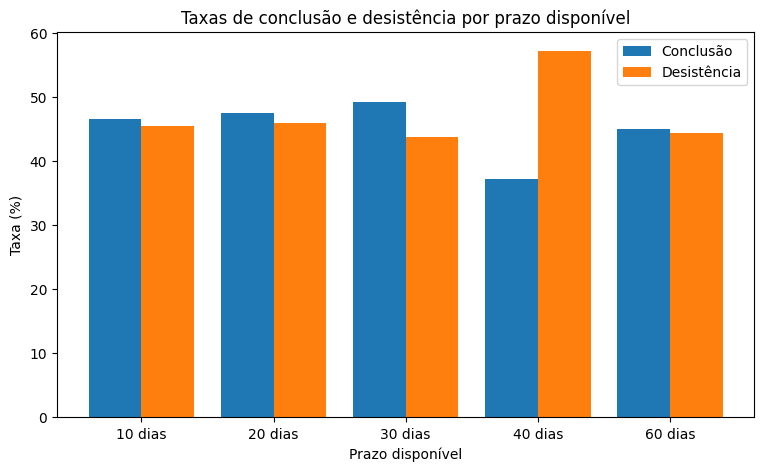

In [37]:
dados_grafico = prazo_status.sort_values("prazo_dias")

x = range(len(dados_grafico))

plt.figure(figsize=(9, 5))

plt.bar(
    [i - 0.2 for i in x],
    dados_grafico["taxa_conclusao"],
    width=0.4,
    label="Conclusão"
)

plt.bar(
    [i + 0.2 for i in x],
    dados_grafico["taxa_desistencia"],
    width=0.4,
    label="Desistência"
)

plt.xticks(
    x,
    [f"{prazo} dias" for prazo in dados_grafico["prazo_dias"]]
)

plt.xlabel("Prazo disponível")
plt.ylabel("Taxa (%)")
plt.title("Taxas de conclusão e desistência por prazo disponível")
plt.legend()

plt.show()

**Interpretação:** Os principais prazos disponíveis apresentam diferenças nos padrões de conclusão e desistência, mas não se observa uma relação linear entre o aumento do prazo e os resultados das matrículas.

Nos cursos com prazo de 10 e 20 dias, as taxas de conclusão e desistência permanecem próximas. O prazo de 30 dias, que concentra a maior parte das interações analisadas, apresenta taxa de conclusão de aproximadamente 49,21% e desistência de 43,79%. Já entre as matrículas com prazo de 40 dias observa-se a maior diferença, com conclusão de 37,30% e desistência de 57,30%. Nos cursos com prazo de 60 dias, as taxas voltam a apresentar valores próximos, com 45,08% de conclusão e 44,50% de desistência.

Portanto, os resultados não indicam que a simples disponibilidade de um prazo maior esteja associada a maiores taxas de conclusão. As diferenças observadas podem estar relacionadas também a outras características dos cursos que utilizam cada prazo, como carga horária, temática ou público-alvo. Dessa forma, o prazo disponível pode contribuir para a caracterização dos cursos, mas seus resultados devem ser interpretados em conjunto com outras informações.

## 6. Evolução temporal das interações

**Pergunta:** Como as interações dos usuários com os cursos se distribuem ao longo do tempo?

A dimensão temporal é relevante para compreender a evolução da utilização da plataforma e também para orientar posteriormente a estratégia de avaliação do sistema de recomendação. Em especial, a ordem cronológica das interações deve ser considerada para evitar que informações futuras sejam utilizadas na previsão de comportamentos anteriores.

Inicialmente, será analisada a quantidade de interações registrada em cada ano da base histórica.

In [38]:
interacoes_por_ano = con.execute(f"""
    SELECT
        EXTRACT(YEAR FROM dt_matricula) AS ano,
        COUNT(*) AS qtd_interacoes,
        COUNT(DISTINCT codigo_pessoa) AS qtd_usuarios
    FROM read_parquet('{arquivo_interacoes.as_posix()}')
    GROUP BY ano
    ORDER BY ano
""").df()

interacoes_por_ano

,ano,qtd_interacoes,qtd_usuarios
0,2006,1878,1828
1,2007,5294,4620
2,2008,8367,7655
3,2009,2759,2639
4,2010,4868,4783
5,2011,4989,4691
6,2012,4393,4179
7,2013,11351,8574
8,2014,36639,27304
9,2015,85183,56654


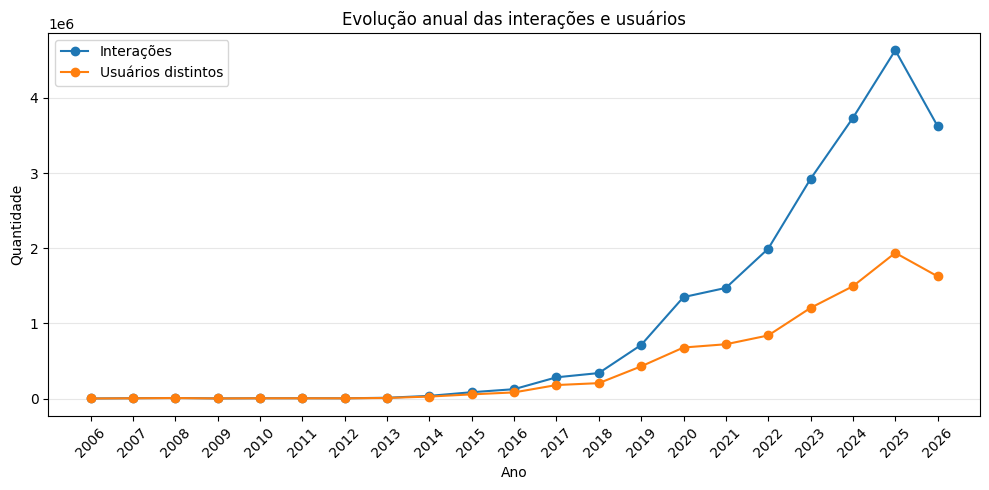

In [39]:
plt.figure(figsize=(10, 5))

plt.plot(
    interacoes_por_ano["ano"],
    interacoes_por_ano["qtd_interacoes"],
    marker="o",
    label="Interações"
)

plt.plot(
    interacoes_por_ano["ano"],
    interacoes_por_ano["qtd_usuarios"],
    marker="o",
    label="Usuários distintos"
)

plt.xlabel("Ano")
plt.ylabel("Quantidade")
plt.title("Evolução anual das interações e usuários")
plt.xticks(interacoes_por_ano["ano"], rotation=45)
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretação:** A distribuição temporal evidencia crescimento expressivo no volume de interações e de usuários ao longo do histórico analisado, especialmente nos anos mais recentes. Em 2019 foram registradas aproximadamente 714 mil interações, enquanto em 2025 esse número alcançou cerca de 4,63 milhões. No mesmo período, o número de usuários distintos com interações passou de aproximadamente 429 mil para 1,94 milhão.

Os registros de 2026 não devem ser diretamente comparados aos anos completos anteriores, pois a base utilizada contém dados somente até setembro desse ano.

Além de caracterizar a evolução da utilização da plataforma, a presença de uma dimensão temporal reforça a necessidade de considerar a ordem cronológica das interações na etapa de avaliação do sistema de recomendação. Uma separação temporal entre dados de treinamento e teste pode evitar o uso de informações futuras para recomendar ou avaliar interações ocorridas anteriormente. 

### 6.1 Evolução temporal das situações de matrícula

**Pergunta:** O crescimento do número de interações ao longo dos anos foi acompanhado por mudanças nas proporções de conclusão e desistência?

Além do crescimento no volume de matrículas, é importante observar se a composição das situações de matrícula também se modificou ao longo do tempo. Essa análise permite identificar possíveis mudanças no comportamento registrado na plataforma e fornece contexto para a futura definição da estratégia temporal de treinamento e avaliação do sistema de recomendação.

In [40]:
status_por_ano = con.execute(f"""
    SELECT
        EXTRACT(YEAR FROM dt_matricula) AS ano,
        COUNT(*) AS total_interacoes,

        SUM(CASE
            WHEN sit_matricula = 'Concluida'
            THEN 1 ELSE 0
        END) AS concluidas,

        SUM(CASE
            WHEN sit_matricula = 'Desistente'
            THEN 1 ELSE 0
        END) AS desistentes

    FROM read_parquet('{arquivo_interacoes.as_posix()}')

    GROUP BY ano
    ORDER BY ano
""").df()

status_por_ano["taxa_conclusao"] = (
    status_por_ano["concluidas"]
    / status_por_ano["total_interacoes"]
    * 100
)

status_por_ano["taxa_desistencia"] = (
    status_por_ano["desistentes"]
    / status_por_ano["total_interacoes"]
    * 100
)

status_por_ano[
    ["ano", "total_interacoes",
     "taxa_conclusao", "taxa_desistencia"]
]

,ano,total_interacoes,taxa_conclusao,taxa_desistencia
0,2006,1878,64.430245,18.903088
1,2007,5294,51.473366,22.610502
2,2008,8367,44.436477,11.091192
3,2009,2759,49.293222,19.354839
4,2010,4868,76.787182,18.672966
5,2011,4989,66.446182,19.041892
6,2012,4393,69.109948,24.174824
7,2013,11351,55.334332,37.494494
8,2014,36639,45.061274,48.500232
9,2015,85183,47.772443,44.217743


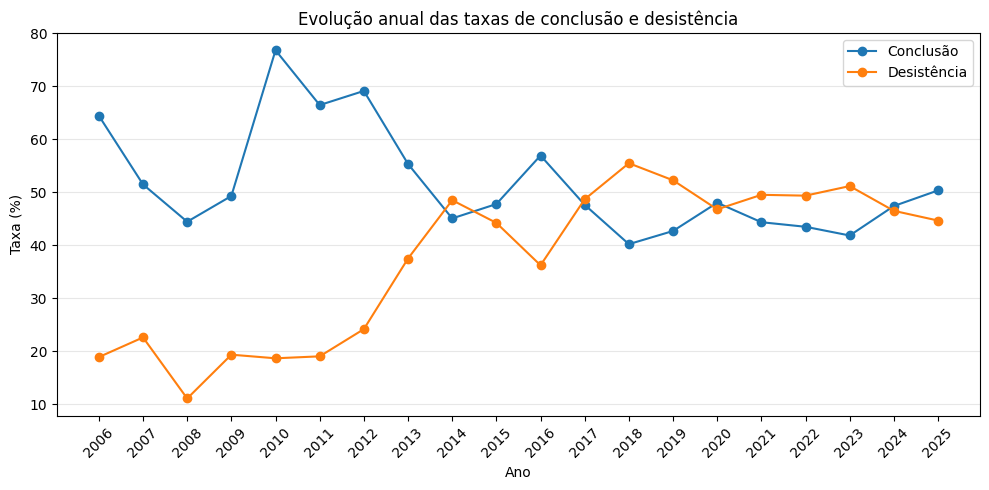

In [41]:
status_anos_completos = status_por_ano[
    status_por_ano["ano"] <= 2025
]

plt.figure(figsize=(10, 5))

plt.plot(
    status_anos_completos["ano"],
    status_anos_completos["taxa_conclusao"],
    marker="o",
    label="Conclusão"
)

plt.plot(
    status_anos_completos["ano"],
    status_anos_completos["taxa_desistencia"],
    marker="o",
    label="Desistência"
)

plt.xlabel("Ano")
plt.ylabel("Taxa (%)")
plt.title("Evolução anual das taxas de conclusão e desistência")

plt.xticks(
    status_anos_completos["ano"],
    rotation=45
)

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

**Interpretação:** As proporções de conclusão e desistência apresentam variações ao longo do período analisado, indicando que o crescimento do volume de interações não ocorreu com uma composição totalmente estável das situações de matrícula.

Nos anos iniciais, em que o volume de interações era consideravelmente menor, são observadas oscilações mais acentuadas. Com o aumento da utilização da plataforma, conclusão e desistência passaram a representar parcelas próximas das interações em diversos períodos, embora existam anos em que uma das situações apresenta predominância. Entre 2018 e 2019 e novamente entre 2021 e 2023, por exemplo, a taxa de desistência superou a de conclusão. Em 2024 as taxas ficaram próximas, enquanto em 2025 a conclusão voltou a apresentar percentual superior.

O ano de 2026 não foi incluído na comparação gráfica por corresponder a um período incompleto na base utilizada, que contém registros somente até setembro. Além disso, matrículas recentes podem ainda estar em andamento, o que exige cautela na comparação de suas situações com anos encerrados.

As variações temporais observadas reforçam a importância de preservar a ordem cronológica das interações na futura estratégia de treinamento e avaliação do sistema de recomendação, evitando fuga de informações entre períodos.

## 7. Situação dos usuários com apenas um curso distinto

**Pergunta:** Como se caracterizam as situações de matrícula dos usuários que interagiram com apenas um curso distinto durante todo o período analisado?

A análise anterior mostrou que 55,44% dos usuários possuem interação com apenas um curso distinto, caracterizando um cenário relevante de esparsidade para o sistema de recomendação.

Entretanto, um único curso distinto não implica necessariamente uma única matrícula, pois um usuário pode se matricular mais de uma vez no mesmo curso. Dessa forma, inicialmente será verificado quantos usuários desse grupo possuem efetivamente apenas uma interação e quantos apresentam matrículas repetidas no mesmo curso.

In [42]:
status_usuarios_um_curso = con.execute(f"""
    WITH usuarios_um_curso AS (
        SELECT
            codigo_pessoa
        FROM read_parquet('{arquivo_interacoes.as_posix()}')
        GROUP BY codigo_pessoa
        HAVING COUNT(DISTINCT id_curso_canonico) = 1
    )

    SELECT
        i.sit_matricula,
        COUNT(*) AS qtd_interacoes,
        COUNT(DISTINCT i.codigo_pessoa) AS qtd_usuarios

    FROM read_parquet('{arquivo_interacoes.as_posix()}') AS i

    INNER JOIN usuarios_um_curso AS u
        ON i.codigo_pessoa = u.codigo_pessoa

    GROUP BY i.sit_matricula
    ORDER BY qtd_usuarios DESC
""").df()

status_usuarios_um_curso

,sit_matricula,qtd_interacoes,qtd_usuarios
0,Desistente,2293382,2182871
1,Concluida,1320901,1276339
2,Não Concluído,119307,119306
3,Reprovado,81186,79685
4,Trancada,30220,29518


In [43]:
perfil_usuarios_um_curso = con.execute(f"""
    WITH usuarios_um_curso AS (
        SELECT
            codigo_pessoa,
            COUNT(*) AS qtd_interacoes
        FROM read_parquet('{arquivo_interacoes.as_posix()}')
        GROUP BY codigo_pessoa
        HAVING COUNT(DISTINCT id_curso_canonico) = 1
    )

    SELECT
        CASE
            WHEN qtd_interacoes = 1
                THEN 'Uma interação'
            ELSE 'Interações repetidas no mesmo curso'
        END AS perfil,
        COUNT(*) AS qtd_usuarios
    FROM usuarios_um_curso
    GROUP BY perfil
    ORDER BY qtd_usuarios DESC
""").df()

perfil_usuarios_um_curso["percentual"] = (
    perfil_usuarios_um_curso["qtd_usuarios"]
    / perfil_usuarios_um_curso["qtd_usuarios"].sum()
    * 100
)

perfil_usuarios_um_curso

,perfil,qtd_usuarios,percentual
0,Uma interação,3347357,93.691488
1,Interações repetidas no mesmo curso,225387,6.308512


### 7.1 Situação dos usuários com exatamente uma interação

Entre os usuários que interagiram com apenas um curso distinto, 93,69% possuem efetivamente uma única interação registrada, enquanto 6,31% apresentam matrículas repetidas no mesmo curso.

Para caracterizar de forma inequívoca a situação da matrícula, a análise a seguir considera somente os usuários com exatamente uma interação. Nesse grupo, cada usuário está associado a uma única situação de matrícula.

In [44]:
status_unica_interacao = con.execute(f"""
    WITH usuarios_uma_interacao AS (
        SELECT
            codigo_pessoa
        FROM read_parquet('{arquivo_interacoes.as_posix()}')
        GROUP BY codigo_pessoa
        HAVING COUNT(*) = 1
    )

    SELECT
        i.sit_matricula,
        COUNT(*) AS qtd_usuarios

    FROM read_parquet('{arquivo_interacoes.as_posix()}') AS i

    INNER JOIN usuarios_uma_interacao AS u
        ON i.codigo_pessoa = u.codigo_pessoa

    GROUP BY i.sit_matricula
    ORDER BY qtd_usuarios DESC
""").df()

status_unica_interacao["percentual"] = (
    status_unica_interacao["qtd_usuarios"]
    / status_unica_interacao["qtd_usuarios"].sum()
    * 100
)

status_unica_interacao

,sit_matricula,qtd_usuarios,percentual
0,Desistente,2000650,59.768050
1,Concluida,1148168,34.300733
2,Não Concluído,112626,3.364625
3,Reprovado,62996,1.881962
4,Trancada,22917,0.684630


**Interpretação:** Entre os 3.347.357 usuários com exatamente uma interação registrada no histórico, 59,77% apresentam situação de desistência, enquanto 34,30% possuem uma conclusão como única interação. As demais situações representam parcelas consideravelmente menores desse grupo.

O resultado evidencia que o problema de esparsidade não está relacionado apenas à pequena quantidade de informações disponíveis por usuário, mas também à natureza do único sinal comportamental observado. Para uma parcela expressiva dos usuários, a única informação disponível é uma matrícula posteriormente classificada como desistência.

Esse cenário representa um desafio para abordagens exclusivamente colaborativas, pois há pouca informação histórica disponível para inferir preferências individuais. Além disso, a desistência não deve ser interpretada automaticamente como rejeição ao conteúdo do curso, uma vez que a análise de interações repetidas mostrou casos em que usuários posteriormente concluíram cursos dos quais haviam desistido anteriormente.

Esses resultados reforçam a relevância de uma abordagem híbrida, na qual informações sobre o conteúdo dos cursos e outros sinais disponíveis possam complementar o histórico comportamental em situações de alta esparsidade.

## 8. Investigação dos cursos com prazo de 40 dias

**Pergunta:** O elevado percentual de desistência observado nas interações com prazo de 40 dias está concentrado em determinados cursos ou características específicas?

A análise anterior identificou taxa de desistência de 57,30% entre as interações com prazo disponível de 40 dias, percentual superior ao observado nos demais prazos mais frequentes.

Para compreender melhor esse resultado, serão investigados os cursos associados a esse prazo, considerando sua concentração de interações, carga horária e temática. O objetivo é verificar se o padrão está associado a um conjunto específico de cursos, sem atribuir causalidade ao prazo disponível.

In [45]:
resumo_cursos_40 = con.execute(f"""
    SELECT
        COUNT(*) AS total_interacoes,
        COUNT(DISTINCT id_curso_canonico) AS qtd_cursos,
        COUNT(DISTINCT codigo_pessoa) AS qtd_usuarios
    FROM read_parquet('{arquivo_interacoes.as_posix()}')
    WHERE DATE_DIFF('day', dt_matricula, dt_fim) = 40
""").df()

resumo_cursos_40

,total_interacoes,qtd_cursos,qtd_usuarios
0,1160186,66,813584


In [46]:
cursos_40_dias = con.execute(f"""
    SELECT
        id_curso_canonico,
        nome_curso,
        carga_horaria,
        tematica,
        COUNT(*) AS qtd_interacoes,
        COUNT(DISTINCT codigo_pessoa) AS qtd_usuarios,

        100.0 * SUM(
            CASE WHEN sit_matricula = 'Concluida'
            THEN 1 ELSE 0 END
        ) / COUNT(*) AS taxa_conclusao,

        100.0 * SUM(
            CASE WHEN sit_matricula = 'Desistente'
            THEN 1 ELSE 0 END
        ) / COUNT(*) AS taxa_desistencia

    FROM read_parquet('{arquivo_interacoes.as_posix()}')

    WHERE DATE_DIFF('day', dt_matricula, dt_fim) = 40

    GROUP BY
        id_curso_canonico,
        nome_curso,
        carga_horaria,
        tematica

    ORDER BY qtd_interacoes DESC
""").df()

cursos_40_dias.head(15)

,id_curso_canonico,nome_curso,carga_horaria,tematica,qtd_interacoes,qtd_usuarios,taxa_conclusao,taxa_desistencia
0,568,Introdução à Libras,60,"Diversidade, Inclusão e Equidade",304205,274343,28.218142,68.685262
1,601,Inteligência Emocional,50,Desenvolvimento Pessoal,146651,132982,39.675829,55.202488
2,183,Segurança do paciente e Qualidade em serviços ...,100,Políticas de Saúde,106159,91489,33.847342,62.067276
3,807,Gestão Pessoal - Base da Liderança,50,Liderança,102401,94949,47.095243,47.806174
4,920,Introdução à Vigilância Sanitária,100,Políticas de Saúde,80583,70333,37.615874,58.885869
5,111,Educação em Direitos Humanos,30,Direitos Humanos,41098,38439,59.835028,33.507713
6,312,Avaliação qualitativa de risco: exposição a ag...,52,Políticas de Saúde,34895,31436,36.366242,56.509529
7,1030,Inteligencia Emocional,50,Desenvolvimento Pessoal,27150,26116,7.734807,73.893186
8,240,Controles na Administração Pública,30,Transparência e Controle,21900,20746,37.543379,57.643836
9,465,Controles Institucional e Social dos Gastos Pú...,30,Transparência e Controle,21340,20285,60.534208,37.014995


In [47]:
cursos_40_ordenados = (
    cursos_40_dias
    .sort_values("qtd_interacoes", ascending=False)
    .reset_index(drop=True)
)

total_40 = cursos_40_ordenados["qtd_interacoes"].sum()

for n in [1, 3, 5, 10]:
    percentual = (
        cursos_40_ordenados
        .head(n)["qtd_interacoes"]
        .sum()
        / total_40
        * 100
    )

    print(f"Top {n}: {percentual:.2f}% das interações")

Top 1: 26.22% das interações
Top 3: 48.01% das interações
Top 5: 63.78% das interações
Top 10: 76.40% das interações


**Interpretação:** Foram identificados 66 cursos associados a interações com prazo disponível de 40 dias. Entretanto, as matrículas não estão distribuídas uniformemente entre esses cursos. O curso mais frequente concentra 26,22% das interações desse grupo, enquanto os três cursos mais frequentes representam 48,01%, os cinco primeiros 63,78% e os dez primeiros 76,40%.

Além da concentração de volume, foram observadas diferenças expressivas nas taxas de conclusão e desistência entre cursos submetidos ao mesmo prazo. Por exemplo, "Introdução à Libras" apresentou 28,22% de conclusão e 68,69% de desistência, enquanto "Educação em Direitos Humanos" apresentou 59,84% de conclusão e 33,51% de desistência.

Dessa forma, a taxa agregada de desistência observada para o prazo de 40 dias não deve ser atribuída isoladamente à duração do prazo. O resultado é influenciado pela composição dos cursos presentes nesse grupo, incluindo diferenças de volume, carga horária, temática e outras características específicas dos cursos.

Para o sistema de recomendação, esse resultado reforça a importância de considerar conjuntamente diferentes características dos itens, evitando interpretar uma única variável, como o prazo disponível, como indicador isolado de preferência ou de probabilidade de conclusão.

In [49]:
catalogo = con.execute(f"""
    SELECT *
    FROM read_parquet('{arquivo_catalogo.as_posix()}')
""").df()

print(f"Dimensão do catálogo: {catalogo.shape[0]} cursos x {catalogo.shape[1]} colunas")
catalogo.info()

Dimensão do catálogo: 1030 cursos x 14 colunas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id_curso_canonico      1030 non-null   int64 
 1   id_curso               1030 non-null   object
 2   nome_curso             1030 non-null   object
 3   eixos_tematicos        998 non-null    object
 4   competencias           402 non-null    object
 5   certificador           1030 non-null   object
 6   conteudista            1030 non-null   object
 7   carga_horaria          1030 non-null   object
 8   disponibilidade_dias   1030 non-null   object
 9   tipo_oferta            1030 non-null   object
 10  apresentacao           1030 non-null   object
 11  publico_alvo           1030 non-null   object
 12  conteudo_programatico  1030 non-null   object
 13  data_lancamento        1030 non-null   object
dtypes: int64(1), object(13)
m

## 9. Análise dos metadados do catálogo de cursos

**Pergunta:** Quais informações estão disponíveis no catálogo para representar o conteúdo e as características dos cursos no componente Content-Based do sistema híbrido?

Como o sistema proposto combina sinais comportamentais com características dos itens, é necessário avaliar a disponibilidade e a completude dos metadados dos 1.030 cursos canônicos.

Inicialmente, será analisado o preenchimento dos campos do catálogo, com atenção especial às informações textuais e estruturais que poderão contribuir para a representação dos cursos.

In [50]:
completude_catalogo = pd.DataFrame({
    "campo": catalogo.columns,
    "preenchidos": catalogo.notna().sum().values,
    "ausentes": catalogo.isna().sum().values
})

completude_catalogo["percentual_preenchido"] = (
    completude_catalogo["preenchidos"]
    / len(catalogo)
    * 100
)

completude_catalogo

,campo,preenchidos,ausentes,percentual_preenchido
0,id_curso_canonico,1030,0,100.000000
1,id_curso,1030,0,100.000000
2,nome_curso,1030,0,100.000000
3,eixos_tematicos,998,32,96.893204
4,competencias,402,628,39.029126
5,certificador,1030,0,100.000000
6,conteudista,1030,0,100.000000
7,carga_horaria,1030,0,100.000000
8,disponibilidade_dias,1030,0,100.000000
9,tipo_oferta,1030,0,100.000000


### 9.1 Completude dos campos textuais

Além dos valores ausentes, foi verificada a ocorrência de textos vazios nos principais campos candidatos à representação dos cursos. Essa distinção é importante porque um campo pode estar registrado na base sem necessariamente possuir conteúdo informativo.

In [52]:
qualidade_textos = []

for campo in campos_textuais:
    serie = catalogo[campo]

    ausentes = serie.isna().sum()

    vazios = (
        serie
        .dropna()
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    utilizaveis = len(catalogo) - ausentes - vazios

    qualidade_textos.append({
        "campo": campo,
        "ausentes": ausentes,
        "vazios": vazios,
        "utilizaveis": utilizaveis,
        "percentual_utilizavel": utilizaveis / len(catalogo) * 100
    })

qualidade_textos = pd.DataFrame(qualidade_textos)

qualidade_textos

,campo,ausentes,vazios,utilizaveis,percentual_utilizavel
0,nome_curso,0,0,1030,100.000000
1,eixos_tematicos,32,0,998,96.893204
2,competencias,628,0,402,39.029126
3,certificador,0,0,1030,100.000000
4,conteudista,0,0,1030,100.000000
5,tipo_oferta,0,0,1030,100.000000
6,apresentacao,0,0,1030,100.000000
7,publico_alvo,0,0,1030,100.000000
8,conteudo_programatico,0,0,1030,100.000000


**Interpretação:** O catálogo apresenta elevada disponibilidade de informações para a representação dos cursos. Os campos `nome_curso`, `certificador`, `conteudista`, `tipo_oferta`, `apresentacao`, `publico_alvo` e `conteudo_programatico` possuem conteúdo utilizável para 100% dos 1.030 cursos canônicos.

O campo `eixos_tematicos` também apresenta alta cobertura, estando disponível em 998 cursos (96,89%). Em contraste, `competencias` possui informação para apenas 402 cursos (39,03%), apresentando 628 valores ausentes.

Não foram identificados textos vazios entre os valores não nulos analisados. Dessa forma, o catálogo oferece ampla cobertura de informações textuais para a construção do componente Content-Based, embora o campo `competencias` não deva ser utilizado isoladamente como principal representação dos cursos devido à sua menor cobertura.

### 9.2 Diversidade dos metadados categóricos

**Pergunta:** Os metadados categóricos apresentam diversidade suficiente para diferenciar os cursos?

Além da completude, a utilidade de uma característica para a representação dos itens depende da variedade de informações disponíveis. Campos preenchidos de forma uniforme podem oferecer pouca capacidade de diferenciação entre os cursos.

In [53]:
campos_categoricos = [
    "eixos_tematicos",
    "certificador",
    "conteudista",
    "tipo_oferta"
]

diversidade_metadados = []

for campo in campos_categoricos:
    serie = catalogo[campo].dropna()

    diversidade_metadados.append({
        "campo": campo,
        "valores_distintos": serie.nunique(),
        "valor_mais_frequente": serie.value_counts().index[0],
        "frequencia_maior": serie.value_counts().iloc[0],
        "percentual_maior": serie.value_counts(normalize=True).iloc[0] * 100
    })

diversidade_metadados = pd.DataFrame(diversidade_metadados)

diversidade_metadados

,campo,valores_distintos,valor_mais_frequente,frequencia_maior,percentual_maior
0,eixos_tematicos,181,Gestão Pública,122,12.224449
1,certificador,2,Enap - Escola Nacional de Administração Pública,1024,99.417476
2,conteudista,106,Enap - Escola Nacional de Administração Pública,266,25.825243
3,tipo_oferta,2,Curso Aberto,1011,98.155340


**Interpretação:** A análise evidencia diferenças importantes na capacidade de discriminação dos metadados categóricos. Embora `certificador` e `tipo_oferta` apresentem preenchimento completo, ambos possuem baixa diversidade: 99,42% dos cursos apresentam a Enap como certificadora e 98,16% são classificados como Curso Aberto. Dessa forma, esses campos oferecem pouca diferenciação entre os itens do catálogo.

O campo `conteudista` apresenta maior diversidade, com 106 valores distintos, enquanto `eixos_tematicos` apresenta 181 valores distintos e menor concentração em seu valor mais frequente. Gestão Pública, o eixo mais recorrente, corresponde a 12,22% dos registros preenchidos.

Entre os metadados categóricos analisados, `eixos_tematicos` apresenta características particularmente relevantes para a representação temática dos cursos no componente Content-Based. A seleção definitiva das variáveis, entretanto, será realizada durante a construção e avaliação do modelo.

In [54]:
eixos_mais_frequentes = (
    catalogo["eixos_tematicos"]
    .dropna()
    .value_counts()
    .head(20)
    .reset_index()
)

eixos_mais_frequentes.columns = ["eixos_tematicos", "qtd_cursos"]

eixos_mais_frequentes

,eixos_tematicos,qtd_cursos
0,Gestão Pública,122
1,Transformação e Governo Digital,75
2,Direito e Legislação,56
3,Gestão de Políticas Públicas,54
4,Inovação,31
5,Análise e Ciência de Dados,23
6,Transparência e Controle,23
7,Gestão de Pessoas,22
8,Governança,19
9,Gestão da Informação e do Conhecimento,18


In [55]:
eixos_com_barra = (
    catalogo[
        catalogo["eixos_tematicos"]
        .fillna("")
        .str.contains("/", regex=False)
    ][["id_curso_canonico", "nome_curso", "eixos_tematicos"]]
)

print(f"Cursos com '/' no campo eixos_tematicos: {len(eixos_com_barra)}")
print(
    f"Percentual dos cursos com eixo preenchido: "
    f"{len(eixos_com_barra) / catalogo['eixos_tematicos'].notna().sum() * 100:.2f}%"
)

eixos_com_barra.head(20)

Cursos com '/' no campo eixos_tematicos: 308
Percentual dos cursos com eixo preenchido: 30.86%


,id_curso_canonico,nome_curso,eixos_tematicos
3,4,Abordagem Lean aplicada à Transformação Digita...,Gestão Pública / Inovação
6,7,"Eixo 4 - Inteligência Artificial, Machine Lear...",Ética e Integridade / Análise e Ciência de Dados
8,9,Obras Públicas: contratação e fiscalização sob...,Políticas de Infraestrutura / Direito e Legisl...
9,10,A Responsabilização Administrativa na Lei Anti...,Transparência e Controle / Direito e Legislação
11,12,Eixo 1 - Questionando o convencional - Program...,Inovação / Liderança
13,14,Introdução ao Exercício do Controle Social,Políticas de Assistência Social / Transparênci...
15,16,Prevenção e Detecção de Cartéis em Licitações,Ética e Integridade / Transparência e Controle
18,19,Vereança em Ação: Princípios Constitucionais e...,Participação e Cidadania / Direito e Legislação
19,20,Parâmetros Nacionais para o Serviço de Atendim...,Direitos Humanos / Políticas de Saúde
22,23,LGPD: Como coordenar a atuação do município pa...,Gestão Federativa / Direito e Legislação


**Interpretação:** Entre os 998 cursos que possuem informação de eixo temático, 308 (30,86%) estão associados a mais de um eixo, representados no catálogo pelo separador `/`. Portanto, os 181 valores distintos identificados anteriormente não correspondem necessariamente a 181 eixos individuais, pois incluem combinações de diferentes temas.

Para caracterizar adequadamente a distribuição temática do catálogo, os eixos múltiplos serão desagregados e contabilizados individualmente. Essa estrutura também é relevante para o componente Content-Based, pois permite preservar relações temáticas compartilhadas entre cursos mesmo quando estes possuem combinações diferentes de eixos.

In [56]:
eixos_individuais = (
    catalogo["eixos_tematicos"]
    .dropna()
    .str.split("/")
    .explode()
    .str.strip()
)

distribuicao_eixos = (
    eixos_individuais
    .value_counts()
    .reset_index()
)

distribuicao_eixos.columns = ["eixo_tematico", "qtd_cursos"]

print(f"Quantidade de eixos temáticos individuais: {eixos_individuais.nunique()}")
print(f"Total de associações curso-eixo: {len(eixos_individuais)}")

distribuicao_eixos.head(20)

Quantidade de eixos temáticos individuais: 42
Total de associações curso-eixo: 1308


,eixo_tematico,qtd_cursos
0,Gestão Pública,178
1,Gestão de Políticas Públicas,111
2,Direito e Legislação,104
3,Transformação e Governo Digital,101
4,Inovação,53
5,Transparência e Controle,50
6,Políticas de Infraestrutura,50
7,Governança,49
8,Participação e Cidadania,48
9,Estratégia e Planejamento,43


### 9.3 Distribuição dos principais eixos temáticos

Após a desagregação dos registros com múltiplos eixos, foram identificados 42 eixos temáticos individuais e 1.308 associações entre cursos e eixos. A seguir, são apresentados os 15 eixos mais frequentes no catálogo.x   

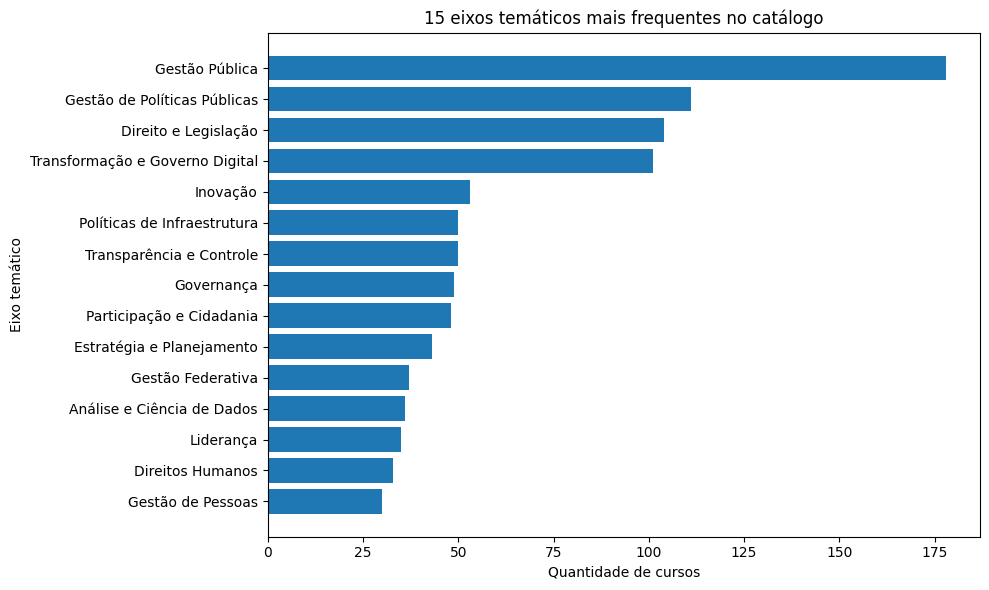

In [57]:
top_eixos = distribuicao_eixos.head(15).sort_values(
    "qtd_cursos",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_eixos["eixo_tematico"],
    top_eixos["qtd_cursos"]
)

plt.xlabel("Quantidade de cursos")
plt.ylabel("Eixo temático")
plt.title("15 eixos temáticos mais frequentes no catálogo")

plt.tight_layout()
plt.show()

**Interpretação:** Após a desagregação das combinações, foram identificados 42 eixos temáticos individuais no catálogo. Gestão Pública é o eixo mais frequente, presente em 178 cursos, seguido por Gestão de Políticas Públicas (111), Direito e Legislação (104) e Transformação e Governo Digital (101).

A existência de 1.308 associações curso-eixo para 998 cursos com essa informação confirma a característica multitemática de parte do catálogo. A distribuição também evidencia diversidade temática entre os cursos, tornando os eixos uma característica potencialmente útil para identificar similaridades de conteúdo.

Para o componente Content-Based, a representação dos eixos deve preservar essa natureza multirrótulo, permitindo que cursos compartilhem similaridade quando possuem um ou mais temas em comum, mesmo que suas combinações completas sejam diferentes.

### 9.4 Caracterização dos metadados textuais

**Pergunta:** Os campos textuais do catálogo apresentam conteúdo suficiente para contribuir para a representação semântica dos cursos?

Além da presença dos campos, será analisado o tamanho dos principais textos disponíveis no catálogo. Essa caracterização permite verificar se as descrições possuem conteúdo textual suficiente para a construção posterior de representações baseadas em texto.

In [58]:
campos_texto_longo = [
    "apresentacao",
    "publico_alvo",
    "conteudo_programatico",
    "competencias"
]

resumo_textos = []

for campo in campos_texto_longo:
    tamanho = (
        catalogo[campo]
        .dropna()
        .astype(str)
        .str.split()
        .str.len()
    )

    resumo_textos.append({
        "campo": campo,
        "qtd_cursos": len(tamanho),
        "media_palavras": tamanho.mean(),
        "mediana_palavras": tamanho.median(),
        "q1": tamanho.quantile(0.25),
        "q3": tamanho.quantile(0.75),
        "minimo": tamanho.min(),
        "maximo": tamanho.max()
    })

resumo_textos = pd.DataFrame(resumo_textos)

resumo_textos

,campo,qtd_cursos,media_palavras,mediana_palavras,q1,q3,minimo,maximo
0,apresentacao,1030,63.738835,65.0,61.0,68.0,2,135
1,publico_alvo,1030,25.820388,23.5,19.0,32.0,1,104
2,conteudo_programatico,1030,34.707767,30.0,20.0,44.0,2,214
3,competencias,402,9.569652,9.0,6.0,13.0,1,41


**Interpretação:** Os principais campos textuais apresentam quantidade relevante de conteúdo para a representação dos cursos. O campo `apresentacao`, disponível para todos os 1.030 cursos, possui média de 63,74 palavras e mediana de 65, com metade dos registros concentrada entre 61 e 68 palavras, indicando descrições relativamente consistentes em extensão.

O campo `publico_alvo` também possui cobertura integral, com média de 25,82 palavras e mediana de 23,5. Já `conteudo_programatico`, igualmente disponível para todos os cursos, apresenta média de 34,71 palavras e maior variação de extensão, alcançando até 214 palavras.

O campo `competencias` apresenta textos mais curtos, com média de 9,57 palavras, além de estar disponível para apenas 402 cursos. Dessa forma, pode fornecer informação complementar quando presente, mas sua menor cobertura limita sua utilização como principal fonte de representação.

Em conjunto, `apresentacao`, `publico_alvo` e `conteudo_programatico` oferecem cobertura completa e conteúdo textual suficiente para serem considerados na construção da representação semântica dos cursos no componente Content-Based. A definição final dos campos e de sua forma de combinação será realizada durante a construção e avaliação do modelo.

## 10. Relações entre características e desempenho dos cursos

**Pergunta:** Existem associações entre características dos cursos, sua popularidade e as taxas observadas de conclusão e desistência?

Para complementar a análise exploratória, serão avaliadas correlações em nível de curso. Cada curso canônico será representado por uma única observação, evitando que cursos com maior número de matrículas tenham peso desproporcional na análise.

Considerando a assimetria observada nas distribuições de popularidade e volume de interações, será utilizada a correlação de Spearman. Os coeficientes serão interpretados como medidas de associação, sem estabelecer relações de causalidade entre as variáveis.

In [60]:
dados_correlacao = con.execute(f"""
    SELECT
        id_curso_canonico,

        MAX(TRY_CAST(carga_horaria AS DOUBLE)) AS carga_horaria,

        COUNT(*) AS qtd_interacoes,

        COUNT(DISTINCT codigo_pessoa) AS qtd_usuarios,

        AVG(
            CASE
                WHEN DATE_DIFF('day', dt_matricula, dt_fim)
                     BETWEEN 0 AND 365
                THEN DATE_DIFF('day', dt_matricula, dt_fim)
            END
        ) AS prazo_medio_dias,

        100.0 * SUM(
            CASE WHEN sit_matricula = 'Concluida'
            THEN 1 ELSE 0 END
        ) / COUNT(*) AS taxa_conclusao,

        100.0 * SUM(
            CASE WHEN sit_matricula = 'Desistente'
            THEN 1 ELSE 0 END
        ) / COUNT(*) AS taxa_desistencia

    FROM read_parquet('{arquivo_interacoes.as_posix()}')

    GROUP BY id_curso_canonico
""").df()

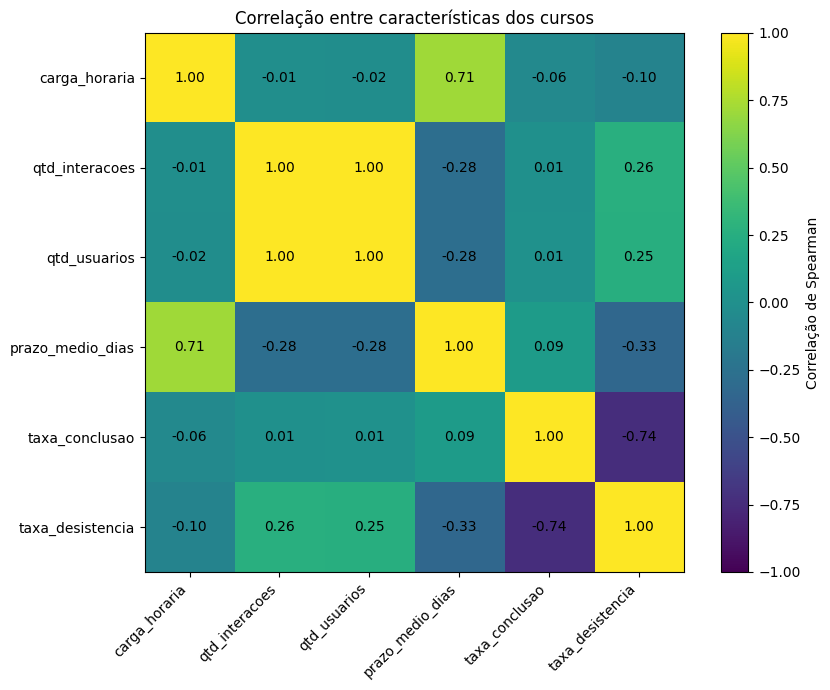

In [61]:
variaveis_correlacao = [
    "carga_horaria",
    "qtd_interacoes",
    "qtd_usuarios",
    "prazo_medio_dias",
    "taxa_conclusao",
    "taxa_desistencia"
]

correlacao_spearman = (
    dados_correlacao[variaveis_correlacao]
    .corr(method="spearman")
)

fig, ax = plt.subplots(figsize=(9, 7))

imagem = ax.imshow(
    correlacao_spearman,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(variaveis_correlacao)))
ax.set_yticks(range(len(variaveis_correlacao)))

ax.set_xticklabels(variaveis_correlacao, rotation=45, ha="right")
ax.set_yticklabels(variaveis_correlacao)

for i in range(len(variaveis_correlacao)):
    for j in range(len(variaveis_correlacao)):
        ax.text(
            j,
            i,
            f"{correlacao_spearman.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

fig.colorbar(imagem, ax=ax, label="Correlação de Spearman")

ax.set_title("Correlação entre características dos cursos")

plt.tight_layout()
plt.show()

**Interpretação:** A matriz de correlação de Spearman evidencia diferentes níveis de associação entre as características analisadas. A quantidade de interações e a quantidade de usuários apresentam correlação praticamente perfeita (1,00), indicando que ambas representam dimensões muito semelhantes da popularidade dos cursos.

A carga horária apresenta correlação positiva de 0,71 com o prazo médio disponível, indicando que cursos de maior duração tendem a estar associados a maiores períodos de disponibilidade. Entretanto, sua associação com as taxas de conclusão (-0,06) e desistência (-0,10) é fraca quando os cursos são analisados de forma agregada.

O prazo médio apresenta correlação de -0,33 com a taxa de desistência e de 0,09 com a taxa de conclusão. Esses resultados indicam associação, mas não permitem concluir que alterações no prazo causem mudanças nas situações de matrícula, especialmente considerando as diferenças de composição, temática e volume existentes entre os cursos.

A taxa de conclusão e a taxa de desistência apresentam correlação negativa de -0,74, resultado esperado pela própria composição das situações de matrícula, uma vez que ambas representam proporções calculadas sobre o total de interações de cada curso.

De modo geral, os resultados reforçam que características isoladas não explicam o comportamento observado nas matrículas. Para o sistema de recomendação, isso favorece a combinação de diferentes fontes de informação, incluindo características dos cursos e histórico comportamental dos usuários.